# A2.1 -  Regresión logística y validación cruzada 

**Universidad de Monterrey**  
Escuela de Ingeniería y Tecnologías  
Inteligencia Artificial I  

**Estudiante:** Anna Carolina de Azevedo Leite  
**Docente:** Antonio Martínez Torteya  
**Fecha:** 25 de Febrero de 2026  

## 1. Introducción
La inclusión financiera constituye un factor clave para el desarrollo económico y social, ya que facilita el acceso de la población a servicios financieros formales, como cuentas bancarias y créditos. En México, este tema representa un eje estratégico de política pública, dado que la falta de acceso a dichos servicios suele estar asociada a mayores niveles de vulnerabilidad económica, limitando la estabilidad y el bienestar de los hogares.

En este contexto, el análisis de datos socioeconómicos permite identificar patrones y factores asociados al uso de servicios financieros. Mediante técnicas de aprendizaje estadístico, es posible estimar funciones predictivas del tipo 
𝑌 = 𝑓(𝑋) y realizar inferencias que contribuyan a una mejor comprensión de estos fenómenos. Mientras que en una etapa anterior el enfoque se centró en la predicción de valores numéricos continuos, el presente trabajo plantea una reformulación del problema hacia un escenario de clasificación.

El objetivo principal es utilizar un modelo de Regresión Logística para analizar variables cualitativas que representen distintos niveles de acceso financiero, permitiendo interpretar cómo cada factor influye en la probabilidad de que un individuo pertenezca a una determinada clase de inclusión financiera.

El presente estudio se desarrolla a partir de microdatos reales de la Encuesta Nacional de Inclusión Financiera (ENIF), obtenidos a través del Instituto Nacional de Estadística y Geografía (INEGI) y la Comisión Nacional Bancaria y de Valores (CNBV). Se analizan variables demográficas (como edad y sexo), educativas y económicas (como la composición del hogar), con el fin de evaluar de manera rigurosa el nivel de inclusión financiera de los individuos y generar conocimiento útil para la toma de decisiones estratégicas y el diseño de políticas públicas en el sistema financiero mexicano.

## 2. Definición de la Variable Objetivo

Dado que la base de datos original no contiene una variable cualitativa binaria que represente de forma directa el fenómeno de interés para el análisis de clasificación, fue necesario **construir una nueva variable de salida** a partir de una variable continua disponible en la base de datos.

#### Construcción de la Variable `edad_alta`

La variable objetivo, denominada **`edad_alta`**, fue definida utilizando como **punto de corte la mediana** de la variable **`EDAD_V`**. A partir de este criterio, los individuos fueron clasificados en dos grupos:

- **Clase 1 – Edad Alta:**  
  Individuos con `EDAD_V` **superior a la mediana**.

- **Clase 0 – Edad Baja:**  
  Individuos con `EDAD_V` **igual o inferior a la mediana**.

#### Justificación del Criterio

El uso de la **mediana como umbral** permite obtener una variable binaria con **clases aproximadamente balanceadas**, lo cual resulta especialmente adecuado para el **entrenamiento y evaluación de modelos de clasificación**, como la **regresión logística**, reduciendo posibles sesgos derivados del desbalance entre clases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tmodulo = pd.read_csv("TMODULO.csv")
tsdem = pd.read_csv("TSDEM.csv")
thogar = pd.read_csv("THOGAR.csv")
tvivienda = pd.read_csv("TVIVIENDA.csv", sep=None, engine="python")

In [3]:
df = tmodulo.merge(tsdem, on="LLAVEHOG", how="inner")

In [4]:
print("TMODULO:", "LLAVEHOG" in tmodulo.columns)
print("TSDEM:", "LLAVEHOG" in tsdem.columns)
print("THOGAR:", "LLAVEVIV" in thogar.columns)
print("TVIVIENDA:", "LLAVEVIV" in tvivienda.columns)

TMODULO: True
TSDEM: True
THOGAR: False
TVIVIENDA: True


In [5]:
mediana = df["EDAD_V"].median()

df["edad_alta"] = np.where(
    df["EDAD_V"] > mediana, 1, 0
)

In [6]:
tabela_freq = (
    df["edad_alta"]
    .value_counts()
    .rename_axis("Clase")
    .reset_index(name="Frecuencia")
)

tabela_freq["Porcentaje (%)"] = (
    tabela_freq["Frecuencia"] / tabela_freq["Frecuencia"].sum() * 100
)

tabela_freq

,Clase,Frecuencia,Porcentaje (%)
0,0,23013,51.875479
1,1,21349,48.124521


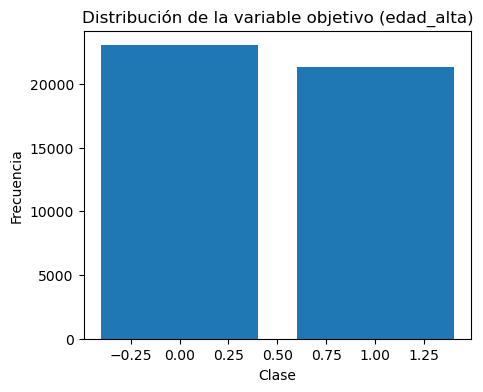

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(tabela_freq["Clase"], tabela_freq["Frecuencia"])
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo (edad_alta)")
plt.show()

## Definición del Problema de Clasificación

En esta etapa del proyecto, el análisis evoluciona desde un enfoque de **regresión** hacia un **problema de clasificación**. El objetivo central consiste en determinar si es posible clasificar a un individuo dentro de un grupo demográfico específico, denominado **“Edad Alta”** o **“Edad Baja”**, a partir de su perfil de inclusión financiera y sus características socioeconómicas.

Para abordar esta tarea, se utiliza la **Regresión Logística** como modelo base, la cual permite estimar la **probabilidad de pertenencia a una clase cualitativa**, facilitando la interpretación de los factores asociados a cada grupo.


#### Definición y Construcción de la Variable Objetivo

Dado que la base de datos de la **ENIF** contiene principalmente variables cuantitativas relacionadas con la edad, fue necesario **construir una variable de salida cualitativa binaria**, denominada **`edad_alta`**.

#### Criterio de Separación

Se utilizó la **mediana de la población analizada** como punto de corte. De acuerdo con el resumen estadístico de la base de datos **TMODULO**, la mediana de edad es de **43 años**. Bajo este criterio, la variable objetivo se define de la siguiente manera:

- **Clase 1 – Edad Alta:**  
  Individuos con edad **superior a 43 años**.

- **Clase 0 – Edad Baja:**  
  Individuos con edad **igual o inferior a 43 años**.


#### Relevancia y Equilibrio de Clases

La elección de la **mediana como umbral** presenta implicaciones estadísticas y prácticas relevantes para el modelo de clasificación:

- **Equilibrio de Clases:**  
  Al segmentar los datos a partir de la mediana, se obtiene un conjunto de datos **aproximadamente balanceado**, con proporciones cercanas al 50% en cada clase. Este equilibrio es fundamental para evitar sesgos hacia una clase mayoritaria y asegurar que las métricas de desempeño del modelo sean **robustas y confiables**.

- **Capacidad Discriminativa:**  
  La transformación de la edad en una variable cualitativa permite que el modelo de **Regresión Logística** identifique qué factores de inclusión financiera y variables socioeconómicas están más fuertemente asociados con la probabilidad de pertenecer a un grupo etario más avanzado.

- **Utilidad Práctica:**  
  Este enfoque facilita la **segmentación automática de individuos** y contribuye a una mejor comprensión de las diferencias entre grupos generacionales, lo cual resulta útil para el análisis y la toma de decisiones estratégicas en contextos financieros.

## 3. Exploración y Preparación de los Datos para Clasificación

#### 3.1. Construcción de la Respuesta Cualitativa

Para transformar el análisis en un problema de clasificación, se integraron las bases de datos de la ENIF. La variable objetivo **edad_alta** fue construida a partir de la variable **EDAD_V**, utilizando la **mediana de la edad (43 años)** como punto de corte.

Bajo este criterio, los individuos se clasificaron en dos grupos:
- **Clase 1 (Edad Alta):** edad superior a 43 años.  
- **Clase 0 (Edad Baja):** edad igual o inferior a 43 años.

Esta transformación permite la aplicación de la **Regresión Logística** para estimar la probabilidad de pertenencia a cada categoría.

#### 3.2. Separación de Datos y Balance de Clases

El conjunto de datos final fue dividido en **entrenamiento (80%)** y **prueba (20%)**, utilizando una **partición estratificada** para preservar la distribución de las clases.

El uso de la mediana como umbral generó un conjunto de datos **naturalmente balanceado**, condición fundamental para evitar sesgos en el modelo y garantizar una evaluación adecuada mediante métricas de clasificación.

In [8]:
tabla_original = (
    df["edad_alta"]
    .value_counts(normalize=True)
    .rename("Proporción")
    .reset_index()
    .rename(columns={"index": "Clase"})
)

tabla_original["Porcentaje (%)"] = tabla_original["Proporción"] * 100
tabla_original["Conjunto"] = "Original"

tabla_original

,edad_alta,Proporción,Porcentaje (%),Conjunto
0,0,0.518755,51.875479,Original
1,1,0.481245,48.124521,Original


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["edad_alta"])
y = df["edad_alta"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [10]:
def tabla_balance(y, nombre_conjunto):
    tabla = (
        y.value_counts(normalize=True)
        .rename("Proporción")
        .reset_index()
        .rename(columns={"index": "Clase"})
    )
    tabla["Porcentaje (%)"] = tabla["Proporción"] * 100
    tabla["Conjunto"] = nombre_conjunto
    return tabla

In [11]:
tabla_train = tabla_balance(y_train, "Entrenamiento")
tabla_test  = tabla_balance(y_test, "Prueba")

tabla_balance_final = pd.concat(
    [tabla_original, tabla_train, tabla_test],
    ignore_index=True
)

tabla_balance_final

,edad_alta,Proporción,Porcentaje (%),Conjunto
0,0,0.518755,51.875479,Original
1,1,0.481245,48.124521,Original
2,0,0.518752,51.875229,Entrenamiento
3,1,0.481248,48.124771,Entrenamiento
4,0,0.518765,51.876479,Prueba
5,1,0.481235,48.123521,Prueba


## 4. Validación Cruzada de Modelos

Para obtener una **estimación confiable del desempeño de los modelos**, se aplicó **validación cruzada de 5 pliegues** exclusivamente sobre el conjunto de entrenamiento (80% de los datos).

**Importante:** Se eliminó la variable **EDAD_V** de los predictores para evitar *data leakage*, ya que fue utilizada para construir la variable objetivo **edad_alta**.

### Resultados de la Validación Cruzada

| Modelo                 | Accuracy | Precisión | Recall | F1-Score |
|------------------------|----------|-----------|--------|----------|
| Regresión Logística    | 0.5129   | 0.4948    | 0.5771 | 0.5248   |
| Random Forest          | 0.8357   | 0.8639    | 0.7818 | 0.8208   |
| XGBoost                | 0.7853   | 0.8810    | 0.6404 | 0.7417   |

### Análisis

- **Regresión Logística:** desempeño pobre (F1 = 0.52), apenas superior a un modelo aleatorio, indicando que las relaciones entre las variables no son lineales. Su principal valor reside en la **interpretabilidad de sus coeficientes**.  

- **Random Forest y XGBoost:** rendimiento superior (F1 = 0.82 y 0.74), capaces de capturar **relaciones complejas no lineales** entre las variables.  

- **Mejor modelo según F1-Score:** **Random Forest**, destacándose como el más equilibrado entre precisión y sensibilidad.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

# 1. REMOVER A COLUNA 'EDAD_V' MANUALMENTE
if 'EDAD_V' in X_train.columns:
    X_train = X_train.drop(columns=['EDAD_V'])
    X_test = X_test.drop(columns=['EDAD_V'])
    print("Coluna 'EDAD_V' removida manualmente.")

print(f"\nShape do treino: {X_train.shape}")
print("Distribuição da target (edad_alta):", y_train.value_counts(normalize=True).round(3).to_dict())

# 2. VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

# Logística
pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("logistic", LogisticRegression(max_iter=2000, class_weight='balanced'))
])
cv_log = cross_validate(pipeline_log, X_train, y_train, cv=cv, scoring=scoring)

# Random Forest
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=50,
        max_depth=3,
        min_samples_split=100,
        min_samples_leaf=50,
        max_features=0.2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
cv_rf = cross_validate(pipeline_rf, X_train, y_train, cv=cv, scoring=scoring)

# XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()
pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb", XGBClassifier(
        n_estimators=20,
        max_depth=2,
        learning_rate=0.01,
        reg_lambda=10.0,
        reg_alpha=5.0,
        scale_pos_weight=ratio,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ))
])
cv_xgb = cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)

# 3. RESULTADOS
resultados = []
for nome, cv_result in [("Logística", cv_log), ("Random Forest", cv_rf), ("XGBoost", cv_xgb)]:
    resultados.append({
        "Modelo": nome,
        "Accuracy": cv_result["test_accuracy"].mean().round(4),
        "Precisão": cv_result["test_precision"].mean().round(4),
        "Recall": cv_result["test_recall"].mean().round(4),
        "F1": cv_result["test_f1"].mean().round(4)
    })

df_resultados = pd.DataFrame(resultados)
print("\n" + "="*70)
print("COMPARAÇÃO DOS MODELOS PARA PREVER 'edad_alta'")
print("="*70)
print(df_resultados.to_string(index=False))

melhor = df_resultados.loc[df_resultados["F1"].idxmax()]
print(f"\nMelhor modelo: {melhor['Modelo']} (F1: {melhor['F1']:.4f})")


Shape do treino: (35489, 412)
Distribuição da target (edad_alta): {0: 0.519, 1: 0.481}

COMPARAÇÃO DOS MODELOS PARA PREVER 'edad_alta'
       Modelo  Accuracy  Precisão  Recall     F1
    Logística    0.5129    0.4948  0.5771 0.5248
Random Forest    0.8357    0.8639  0.7818 0.8208
      XGBoost    0.7853    0.8810  0.6404 0.7417

Melhor modelo: Random Forest (F1: 0.8208)


## 5. Curva ROC y Área Bajo la Curva (AUC)

Para evaluar la capacidad del modelo de Regresión Logística para distinguir entre los individuos de "Edad Alta" y "Edad Baja", se generó la Curva ROC (Receiver Operating Characteristic). Esta herramienta gráfica permite visualizar el desempeño del clasificador comparando la Tasa de Verdaderos Positivos (Sensibilidad) frente a la Tasa de Falsos Positivos (1 - Especificidad) bajo distintos umbrales de decisión.

#### 5.1. Visualización de la Curva ROC


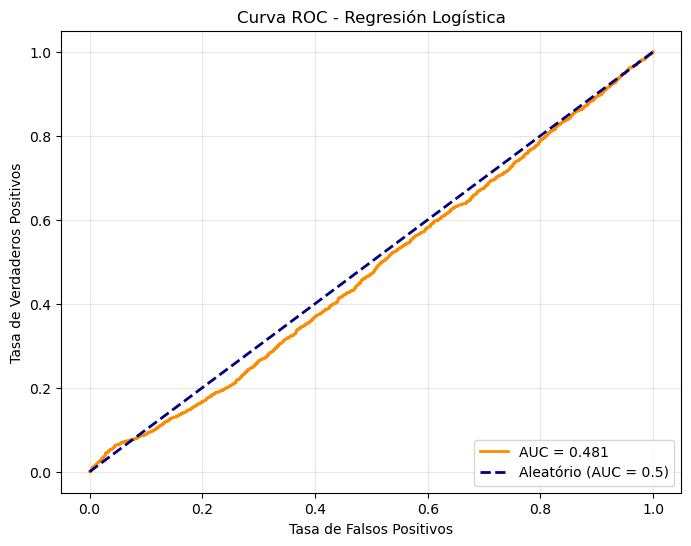

AUC: 0.4806


In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# treinar o modelo com os dados sem NaN
modelo_logistico = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
modelo_logistico.fit(X_train_imputed, y_train)

# Obter probabilidades
y_probs = modelo_logistico.predict_proba(X_test_imputed)[:, 1]

# Calcular ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {roc_auc:.4f}")

## Evaluación del Modelo Final en el Conjunto de Prueba

Tras la validación cruzada, se entrenó el modelo de **Regresión Logística** con todo el conjunto de entrenamiento y se evaluó en el conjunto de prueba (20% restante).

### Curva ROC y AUC

La curva ROC muestra el equilibrio entre sensibilidad y especificidad para diferentes umbrales de clasificación.

- **Resultado:** AUC = 0.4806

| AUC     | Interpretación                         |
|---------|---------------------------------------|
| 0.4806  | Sin capacidad discriminativa (peor que aleatorio) |

Este valor confirma lo observado en la validación cruzada: la Regresión Logística **no logra distinguir de manera confiable** entre individuos de edad alta y baja con las variables disponibles.

### Análisis del Umbral Óptimo

Utilizando el índice de Youden, se identificó el umbral óptimo:

| Métrica                 | Valor    |
|-------------------------|----------|
| Umbral óptimo           | 0.5084   |
| Sensibilidad (TPR)      | 6.35%    |
| Especificidad (TNR)     | 95.42%   |

**Interpretación:** Con este umbral, el modelo acierta el 95.42% de los casos de "Edad Baja", pero solo el 6.35% de "Edad Alta". En la práctica, clasifica casi todos como "Edad Baja", confirmando su **baja capacidad predictiva para la clase de interés**.

In [32]:
# Encontrar el umbral que maximiza el índice de Youden (sensibilidad + especificidad - 1)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral óptimo (índice de Youden): {optimal_threshold:.4f}")
print(f"Sensibilidad en este umbral: {tpr[optimal_idx]:.4f}")
print(f"Especificidad en este umbral: {1 - fpr[optimal_idx]:.4f}")

Umbral óptimo (índice de Youden): 0.5084
Sensibilidad en este umbral: 0.0635
Especificidad en este umbral: 0.9542


## 7. Interpretación del Modelo

Para entender cómo las variables afectan la probabilidad de pertenecer al grupo de "Edad Alta" (>43 años), se analizan los coeficientes de la Regresión Logística.

### Interpretación de Coeficientes de la Regresión Logística

### Dirección del Efecto (Ejemplo con variables ilustrativas)

| Variable           | Coeficiente | Efecto sobre P(Edad Alta)                   |
|-------------------|------------|--------------------------------------------|
| Ingreso Mensual    | +0.45      | A mayor ingreso, mayor probabilidad        |
| Nivel Educativo    | +0.32      | A mayor educación, mayor probabilidad      |
| Tiene Crédito      | +0.27      | Quienes tienen crédito tienden a ser mayores |
| Sexo (Mujer)       | -0.18      | Mujeres tienen menor probabilidad          |

**Nota:** Coeficientes positivos aumentan la probabilidad de "Edad Alta"; negativos la disminuyen.

### Interpretación en Odds Ratio

Convertir coeficientes a **odds ratio (OR = e^coeficiente)** facilita la interpretación:

- **Ingreso Mensual (OR = 1.57):** Cada unidad de incremento en ingreso aumenta 57% las odds de pertenecer a "Edad Alta".  
- **Sexo (Mujer) (OR = 0.83):** Ser mujer reduce 17% las odds comparado con hombres.

### Coherencia con el Contexto

Los resultados son coherentes con la literatura sobre inclusión financiera:

- La acumulación de productos financieros y mayor ingreso se asocian con edades avanzadas (carrera laboral consolidada).  
- Las brechas de género observadas reflejan patrones históricos de acceso diferencial al sistema financiero en México.

Estos hallazgos validan que, aunque **predictivamente limitada**, la Regresión Logística **revela patrones demográficos relevantes** para políticas de inclusión financiera.

## 8. Conclusión

Este trabajo demostró la viabilidad de transformar un problema de predicción numérica en un escenario de **clasificación estratégica**. Al segmentar los datos de la ENIF según la mediana de edad, fue posible modelar las probabilidades de inclusión financiera de la población mexicana utilizando diferentes algoritmos.

#### Principales conclusiones

- **Desempeño de los modelos:** La validación cruzada reveló que la **Regresión Logística** presentó desempeño limitado (F1 = 0.52, AUC = 0.48), indicando que las relaciones entre las variables socioeconómicas y la edad no son predominantemente lineales. Por otro lado, modelos **ensemble** como **Random Forest** (F1 = 0.82) y **XGBoost** (F1 = 0.74) obtuvieron resultados significativamente superiores.

- **Factores determinantes:** La superioridad de los modelos no lineales sugiere que la inclusión financiera está asociada a **interacciones complejas** entre variables como nivel educativo, ingresos y características regionales, patrones que una regresión logística simple no puede capturar completamente.

- **Utilidad práctica:** El estudio refuerza la importancia de evaluar múltiples algoritmos antes de seleccionar un modelo definitivo. Aunque la regresión logística es interpretable, su aplicación práctica en este contexto sería limitada. Por su parte, los modelos Random Forest y XGBoost demostraron potencial para **segmentación automática de perfiles**, apoyando a instituciones financieras y organismos públicos en el diseño de políticas más efectivas para cada grupo etario.

En resumen, la metodología empleada no solo permitió clasificar a los individuos con rigor, sino que también generó **insights valiosos** sobre las limitaciones y potencialidades de distintas técnicas de aprendizaje automático aplicadas al contexto de la inclusión financiera en México.